In [2]:
#Librerias requeridas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de datos
df = pd.read_spss('../data/raw/201512_EnemduBDD_con.SAV')

# Ver los primeros datos
df.head()

,area,ciudad,zona,sector,panelm,vivienda,hogar,c01,c02,c03,...,c07,c08,c09,c10,c11,c12,c13,id_sector,plan_muestreo,fexp
0,Urbana,10150.0,001,003,Panel A2,Vivienda Uno,Hogar Uno,Igual,Igual,Menor,...,Igual,Igual,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
1,Urbana,10150.0,001,003,Panel A2,Vivienda Dos,Hogar Uno,Peor,Peor,Menor,...,Igual,Igual,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
2,Urbana,10150.0,001,003,Panel A2,Vivienda Tres,Hogar Uno,Peor,Peor,Menor,...,Menor,Menor,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
3,Urbana,10150.0,001,003,Panel B2,Vivienda Uno,Hogar Uno,Igual,Igual,Menor,...,Menor,Menor,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774
4,Urbana,10150.0,001,003,Panel B2,Vivienda Dos,Hogar Uno,Igual,Igual,Menor,...,Menor,Menor,No,No,No,Peor,Peor,1.015000e+10,1013,64.249774


In [3]:
#Carga de datos
df = pd.read_spss('../data/raw/201512_EnemduBDD_15anios.sav')

# Ver los primeros datos
df.head()

,area,ciudad,zona,sector,panelm,vivienda,hogar,p01,p02,p03,...,nc,desem,desemab,desemoc,desem1,desem2,pein,id_sector,plan_muestreo,fexp
0,1.0,10150.0,009,004,Panel B2,Vivienda Uno,Hogar Uno,Persona 3,Hombre,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.015001e+10,1012,141.065750
1,1.0,10150.0,056,005,Panel A2,Vivienda Tres,Hogar Uno,Persona 1,Hombre,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Población Económicamente Inactiva,1.015006e+10,1012,65.976281
2,1.0,70150.0,005,001,Panel B2,Vivienda Dos,Hogar Dos,Persona 1,Hombre,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.015001e+10,1072,123.512430
3,1.0,70150.0,043,004,Panel B2,Vivienda Uno,Hogar Uno,Persona 1,Hombre,38.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.015004e+10,1071,96.697327
4,1.0,80150.0,012,003,Panel A2,Vivienda Uno,Hogar Uno,Persona 1,Hombre,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.015001e+10,1081,89.319663


In [5]:
import os
import pandas as pd

folder_path = '../data/raw/'
all_dfs = []

# 1. Listar solo archivos que sean de "Personas" o bases completas
# Evitamos los que terminan en '_con.sav' (que suelen ser de Hogares)
archivos = [f for f in os.listdir(folder_path) if f.endswith('.sav') and 'persona' in f.lower() or '15anios' in f.lower()]

for archivo in archivos:
    print(f"--- Procesando: {archivo} ---")
    
    try:
        # Cargar archivo
        temp_df = pd.read_spss(os.path.join(folder_path, archivo))
        
        # Estandarizar nombres a minúsculas para evitar errores de 'AREA' vs 'area'
        temp_df.columns = temp_df.columns.str.lower()
        
        # Definir las columnas que queremos (en minúsculas)
        columnas_deseadas = ['area', 'p02', 'p03', 'fexp']
        
        # 2. Verificar cuáles de estas columnas existen realmente en este archivo
        columnas_presentes = [col for col in columnas_deseadas if col in temp_df.columns]
        
        if len(columnas_presentes) < len(columnas_deseadas):
            print(f"⚠️ Alerta: Faltan columnas en {archivo}. Solo se encontraron: {columnas_presentes}")
        
        # Extraer solo lo que existe y añadir el año
        # Si el nombre empieza con el año (ej. 2015...), lo extraemos
        anio = "".join(filter(str.isdigit, archivo))[:4] 
        subset = temp_df[columnas_presentes].copy()
        subset['anio_fiscal'] = anio
        
        all_dfs.append(subset)
        
    except Exception as e:
        print(f"❌ Error crítico en {archivo}: {e}")

# Unir todo
if all_dfs:
    df_historico = pd.concat(all_dfs, ignore_index=True)
    print("\n✅ ¡Consolidación completada con éxito!")
    print(df_historico.head())
else:
    print("❌ No se pudo consolidar ningún archivo.")

--- Procesando: 201512_EnemduBDD_15anios.sav ---
--- Procesando: BDDenemdu_personas_2018_anual.sav ---
--- Procesando: BDDenemdu_personas_2019_anual.sav ---
--- Procesando: BDDenemdu_personas_2021_anual.sav ---
--- Procesando: enemdu_persona_2022_12.sav ---
--- Procesando: enemdu_persona_2023_12.sav ---

✅ ¡Consolidación completada con éxito!
  area     p02   p03        fexp anio_fiscal
0  1.0  Hombre  26.0  141.065750        2015
1  1.0  Hombre  68.0   65.976281        2015
2  1.0  Hombre  41.0  123.512430        2015
3  1.0  Hombre  38.0   96.697327        2015
4  1.0  Hombre  64.0   89.319663        2015


In [14]:
# Guardar en formato Pickle (mantiene categorías y tipos de datos de pandas)
df_historico.to_pickle('../data/processed/enemdu_historica_2015_2023.pkl')

print("✅ ¡Logrado! Base guardada en formato Pickle.")

✅ ¡Logrado! Base guardada en formato Pickle.


In [15]:
# Ver cuántos datos tenemos por año y por área
print("Distribución por año y área:")
print(pd.crosstab(df_historico['anio_fiscal'], df_historico['area']))

# Ver qué etiquetas tiene la columna de sexo
print("\nEtiquetas en la variable p02 (Sexo):")
print(df_historico['p02'].value_counts())

Distribución por año y área:
area           1.0    2.0   Rural   Urbana   Rural  Urbana
anio_fiscal                                               
2015         66646  46175       0        0       0       0
2018             0      0       0        0  134872  347676
2019             0      0       0        0  136673  347852
2021             0      0       0        0   97487  264303
2022             0      0    7722    21271       0       0
2023             0      0    7693    20613       0       0

Etiquetas en la variable p02 (Sexo):
p02
Mujer      736472
Hombre     705212
 Mujer      29664
 Hombre     27635
Name: count, dtype: int64


In [16]:
# 1. Eliminar espacios en blanco invisibles al inicio o final de los textos
df_historico['area'] = df_historico['area'].astype(str).str.strip()
df_historico['p02'] = df_historico['p02'].astype(str).str.strip()

# 2. Mapear los códigos numéricos a etiquetas (Basado en metodología INEC)
# 1.0 solía ser Urbana y 2.0 Rural en las bases antiguas
mapeo_area = {
    '1.0': 'Urbana',
    '2.0': 'Rural',
    'nan': 'Sin Dato' # Manejo de nulos si existieran
}

# Aplicar el reemplazo
df_historico['area'] = df_historico['area'].replace(mapeo_area)

# 3. Unificar Sexo (p02)
# Esto corregirá los duplicados de "Mujer" y "Hombre"
mapeo_sexo = {
    '1.0': 'Hombre', # En caso de que algún año venga como número
    '2.0': 'Mujer'
}
df_historico['p02'] = df_historico['p02'].replace(mapeo_sexo)

print("✅ Estandarización completada.")

✅ Estandarización completada.


In [17]:
# Verificación final
print("Distribución unificada por Área:")
print(pd.crosstab(df_historico['anio_fiscal'], df_historico['area']))

print("\nEtiquetas unificadas de Sexo:")
print(df_historico['p02'].value_counts())

Distribución unificada por Área:
area          Rural  Urbana
anio_fiscal                
2015          46175   66646
2018         134872  347676
2019         136673  347852
2021          97487  264303
2022           7722   21271
2023           7693   20613

Etiquetas unificadas de Sexo:
p02
Mujer     766136
Hombre    732847
Name: count, dtype: int64


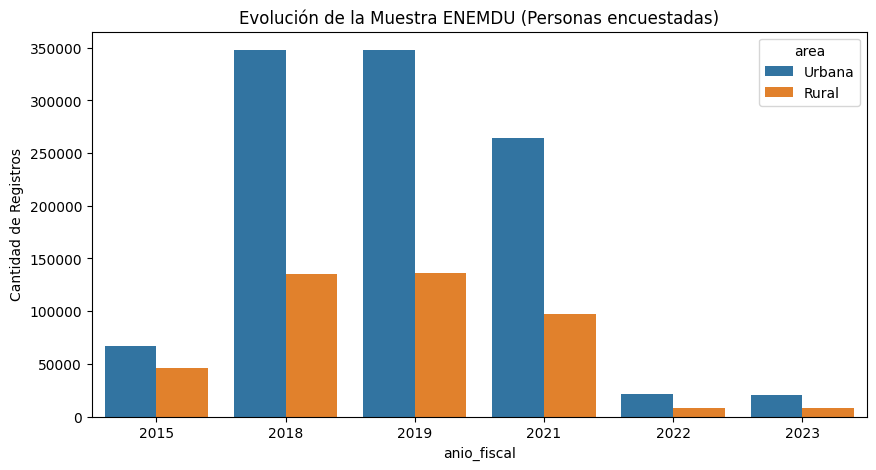

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Graficamos el conteo de personas por año y área
sns.countplot(data=df_historico, x='anio_fiscal', hue='area')
plt.title('Evolución de la Muestra ENEMDU (Personas encuestadas)')
plt.ylabel('Cantidad de Registros')
plt.show()

In [19]:
columnas_deseadas = ['area', 'p02', 'p03', 'fexp', 'ingpc', 'pobreza', 'epobreza']
all_dfs = []

for archivo in archivos:
    print(f"Buscando variables en: {archivo}...")
    temp_df = pd.read_spss(os.path.join(folder_path, archivo))
    temp_df.columns = temp_df.columns.str.lower()
    
    # Identificar qué columnas de la lista existen en este archivo
    presentes = [col for col in columnas_deseadas if col in temp_df.columns]
    
    anio = "".join(filter(str.isdigit, archivo))[:4]
    subset = temp_df[presentes].copy()
    subset['anio_fiscal'] = anio
    all_dfs.append(subset)

df_historico = pd.concat(all_dfs, ignore_index=True)

# Volvemos a estandarizar etiquetas (como hicimos antes)
df_historico['area'] = df_historico['area'].astype(str).str.strip().replace({'1.0': 'Urbana', '2.0': 'Rural'})
df_historico['p02'] = df_historico['p02'].astype(str).str.strip().replace({'1.0': 'Hombre', '2.0': 'Mujer'})

# Guardamos la versión completa
df_historico.to_pickle('../data/processed/enemdu_historica_completa.pkl')
print("✅ Base histórica actualizada con variables de pobreza.")

Buscando variables en: 201512_EnemduBDD_15anios.sav...
Buscando variables en: BDDenemdu_personas_2018_anual.sav...
Buscando variables en: BDDenemdu_personas_2019_anual.sav...
Buscando variables en: BDDenemdu_personas_2021_anual.sav...
Buscando variables en: enemdu_persona_2022_12.sav...
Buscando variables en: enemdu_persona_2023_12.sav...
✅ Base histórica actualizada con variables de pobreza.


In [20]:
import os
import pandas as pd

# Definimos las variables objetivo y sus posibles variantes de nombre
# ingpc: Ingreso Per Cápita, p10a: Nivel de instrucción, pobreza: Indicador ya calculado
columnas_objetivo = ['area', 'p02', 'p03', 'fexp', 'ingpc', 'p10a', 'pobreza', 'epobreza']
folder_path = '../data/raw/'
all_dfs = []

# Filtrar archivos de personas
archivos = [f for f in os.listdir(folder_path) if f.endswith('.sav') and ('persona' in f.lower() or '15anios' in f.lower())]

for archivo in archivos:
    print(f"🔄 Procesando variables en: {archivo}...")
    try:
        temp_df = pd.read_spss(os.path.join(folder_path, archivo))
        temp_df.columns = temp_df.columns.str.lower()
        
        # Identificar qué columnas de nuestra lista existen en este archivo específico
        columnas_presentes = [col for col in columnas_objetivo if col in temp_df.columns]
        
        # Extraer año
        anio = "".join(filter(str.isdigit, archivo))[:4]
        
        # Crear copia con las columnas encontradas
        subset = temp_df[columnas_presentes].copy()
        subset['anio_fiscal'] = anio
        
        all_dfs.append(subset)
        print(f"   ✅ Columnas rescatadas: {len(columnas_presentes)}")
        
    except Exception as e:
        print(f"   ❌ Error en {archivo}: {e}")

# Unir todo el historial
df_historico = pd.concat(all_dfs, ignore_index=True)

# --- ESTANDARIZACIÓN MAESTRA ---
# 1. ÁREA: Unificar etiquetas y códigos
df_historico['area'] = df_historico['area'].astype(str).str.strip().replace({'1.0': 'Urbana', '2.0': 'Rural'})

# 2. SEXO: Unificar etiquetas y códigos
df_historico['p02'] = df_historico['p02'].astype(str).str.strip().replace({'1.0': 'Hombre', '2.0': 'Mujer'})

# 3. EDUCACIÓN (p10a): Limpiar espacios
if 'p10a' in df_historico.columns:
    df_historico['p10a'] = df_historico['p10a'].astype(str).str.strip()

# Guardar la versión final en Pickle
df_historico.to_pickle('../data/processed/enemdu_historica_completa.pkl')

print("\n🚀 ¡TODO LISTO! Base histórica completa y guardada.")
print(f"Forma final del dataset: {df_historico.shape}")

🔄 Procesando variables en: 201512_EnemduBDD_15anios.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: BDDenemdu_personas_2018_anual.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: BDDenemdu_personas_2019_anual.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: BDDenemdu_personas_2021_anual.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: enemdu_persona_2022_12.sav...
   ✅ Columnas rescatadas: 8
🔄 Procesando variables en: enemdu_persona_2023_12.sav...
   ✅ Columnas rescatadas: 8

🚀 ¡TODO LISTO! Base histórica completa y guardada.
Forma final del dataset: (1498983, 9)


In [21]:
# Ver las categorías de educación (p10a)
print("Categorías de nivel de instrucción (p10a):")
print(df_historico['p10a'].value_counts().head(10))

# Ver estadísticas descriptivas del ingreso per cápita
print("\nResumen del Ingreso Per Cápita (ingpc):")
print(df_historico.groupby('anio_fiscal')['ingpc'].describe())

Categorías de nivel de instrucción (p10a):
p10a
Educación Básica             327280
Primaria                     298906
Secundaria                   294657
Superior Universitario       221388
Educación  Media             162442
Ninguno                       45644
Superior no universitario     24130
Post-grado                    20020
Centro de alfabetización       3280
Name: count, dtype: int64

Resumen del Ingreso Per Cápita (ingpc):
                count        mean         std       min         25%  \
anio_fiscal                                                           
2015         111694.0  215.554712  301.790347  0.250000   78.000000   
2018         479125.0  276.519599  365.931660  0.333333  105.000000   
2019         480984.0  276.729105  385.876808  0.333333  105.000000   
2021         357828.0  250.251599  405.132141  0.200000   90.000000   
2022          28831.0  296.543269  384.592113  0.600000  110.000000   
2023          28162.0  292.353917  319.925278  1.000000  112.857

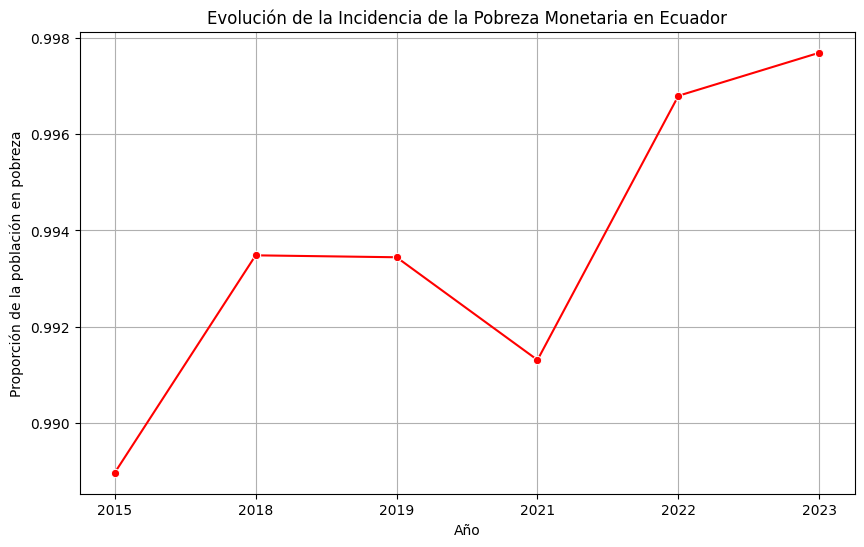

In [22]:
# Creamos una columna numérica para facilitar el cálculo si 'pobreza' es texto
df_historico['es_pobre'] = (df_historico['pobreza'].astype(str).str.contains('Pobre', case=False)).astype(int)

# Cálculo de la tasa de pobreza ponderada por año
def tasa_pobreza(group):
    return (group['es_pobre'] * group['fexp']).sum() / group['fexp'].sum()

pobreza_anual = df_historico.groupby('anio_fiscal').apply(tasa_pobreza).reset_index()
pobreza_anual.columns = ['anio_fiscal', 'tasa_pobreza']

# Visualización
plt.figure(figsize=(10, 6))
sns.lineplot(data=pobreza_anual, x='anio_fiscal', y='tasa_pobreza', marker='o', color='red')
plt.title('Evolución de la Incidencia de la Pobreza Monetaria en Ecuador')
plt.ylabel('Proporción de la población en pobreza')
plt.xlabel('Año')
plt.grid(True)
plt.show()

In [23]:
# Ver exactamente qué etiquetas hay en la columna de pobreza
print("Etiquetas encontradas en la variable pobreza:")
print(df_historico['pobreza'].value_counts())

Etiquetas encontradas en la variable pobreza:
pobreza
NO POBRE    1194931
POBRE        291693
Name: count, dtype: int64


In [25]:
# El secreto está en añadir .str antes de .strip()
df_historico['es_pobre'] = (df_historico['pobreza'].astype(str).str.strip() == 'Pobre').astype(int)
print("Etiquetas reales en la base:")
print(df_historico['pobreza'].unique())

Etiquetas reales en la base:
['NO POBRE', NaN, 'POBRE']
Categories (2, str): ['NO POBRE', 'POBRE']


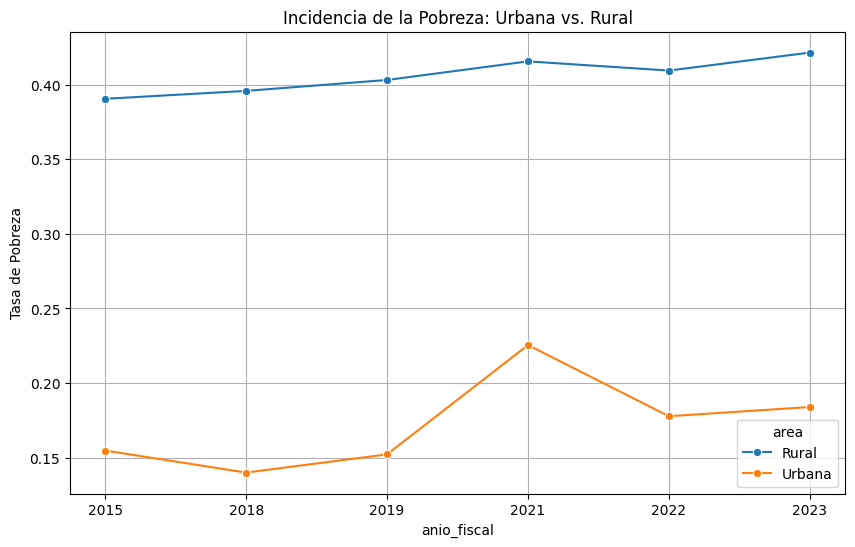

In [31]:
# 1. Definimos la función (para que Python la "conozca")
def tasa_pobreza_real(group):
    # Usamos fexp para que el cálculo sea estadísticamente representativo
    return (group['es_pobre'] * group['fexp']).sum() / group['fexp'].sum()

# 2. Corregimos la lógica para que coincida con tus etiquetas en MAYÚSCULAS
# Usamos .upper() para asegurarnos de que no importe cómo esté escrito
df_historico['es_pobre'] = (df_historico['pobreza'].astype(str).str.strip().str.upper() == 'POBRE').astype(int)

# 3. Ahora sí, calculamos la pobreza por año y área
pobreza_area = df_historico.groupby(['anio_fiscal', 'area']).apply(tasa_pobreza_real).reset_index()
pobreza_area.columns = ['anio_fiscal', 'area', 'tasa_pobreza']

# 4. Graficamos
plt.figure(figsize=(10, 6))
sns.lineplot(data=pobreza_area, x='anio_fiscal', y='tasa_pobreza', hue='area', marker='o')
plt.title('Incidencia de la Pobreza: Urbana vs. Rural')
plt.ylabel('Tasa de Pobreza')
plt.grid(True)
plt.show()